Завод по производству деталей утверждает, что за одну смену сотрудником производится 120 деталей.

Для проверки заявления было измерено количество средних деталей в день у 10 сотрудников. Необходимо на уровне значимости 5% проверить, является ли среднее количетво произведённых деталей — 120.

Нулевая гипотеза: одним сотрудником в среднем производится 120 деталей.</br>
Альтернативная гипотеза: одним сотрудником в среднем не производится 120 деталей.

In [1]:
from scipy import stats as sts
from scipy.stats import t
import numpy as np
from matplotlib import pyplot as plt

In [2]:
mu_0 = 120 #Средняя выработка деталей за смену. Нулевая гипотеза
print(f'Среднее предполагаемое за смену: {mu_0}')

data = [115, 122, 118, 125, 117, 121, 119, 123, 116, 120] #Выборка по средним деталям за смену из 10 рабочих
n = len(data)
df = n-1 #Степень свободы

x_bar = np.mean(data) #Среднее выборочное
s = np.std(data, ddof=1) #Стандартное отклонение от среднего выборки
sem = s / np.sqrt(n) #Точность выборочного среднего
t_crit = sts.t.ppf(0.975, df) #Точка накопленной вероятности 97.5%
margin_of_error = t_crit * sem #Предельная ошибка (граница интервала)
#ДИ для mu_0
lower_bound = x_bar - margin_of_error
upper_bound = x_bar + margin_of_error
print(f'Среднее выборочное за смену: {x_bar}')
print(f'95%-й доверительный интервал: [{lower_bound:.2f}-{upper_bound:.2f}]')

Среднее предполагаемое за смену: 120
Среднее выборочное за смену: 119.6
95%-й доверительный интервал: [117.31-121.89]


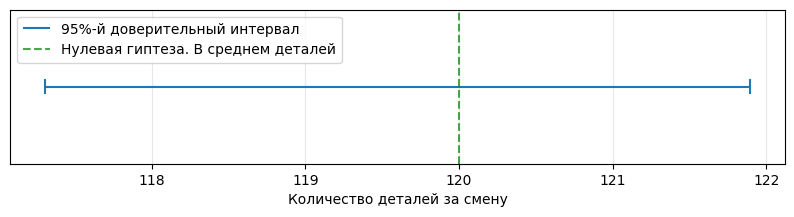

In [3]:
plt.figure(figsize=(10, 2))
plt.hlines(y=0, xmin=lower_bound, xmax=upper_bound, label='95%-й доверительный интервал')
plt.axvline(mu_0, linestyle='--', color='green', alpha=0.7, label='Нулевая гиптеза. В среднем деталей')
plt.vlines(x=lower_bound, ymin=-0.1, ymax=0.1)
plt.vlines(x=upper_bound, ymin=-0.1, ymax=0.1)
plt.ylim(-1, 1)

plt.grid(True, alpha=0.3)
plt.yticks([])
plt.xlabel('Количество деталей за смену')
plt.legend()
plt.show()

In [4]:
t_statistic, p_value = sts.ttest_1samp(data, 120)

print(f't-критичская: {-t_crit:.2f}')
print(f't-statistic: {t_statistic:.2f}')
print(f'p-value: {p_value:.2f}')

t-критичская: -2.26
t-statistic: -0.39
p-value: 0.70


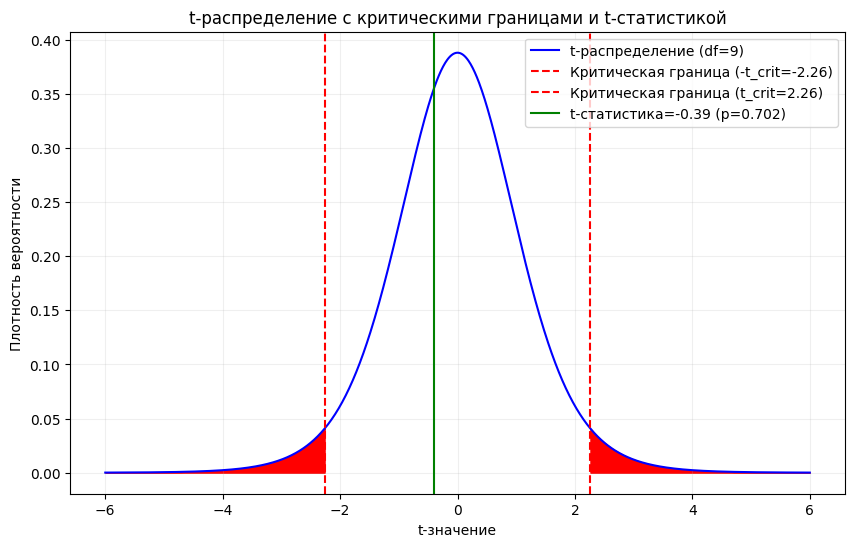

In [5]:
#Значения для кривой
x = np.linspace(-6, 6, 1000)
y = sts.t.pdf(x, df)

#Генерация графика
plt.figure(figsize=(10, 6))
plt.plot(x, y, label=f't-распределение (df={df})', color='b')

#Линии критических границ
plt.axvline(x=-t_crit, label=f'Критическая граница (-t_crit={-t_crit:.2f})' , linestyle='--', color='r')
plt.axvline(x=t_crit, label=f'Критическая граница (t_crit={t_crit:.2f})', linestyle='--', color='r')

#Линия t-статистики
plt.axvline(x=t_statistic, label=f't-статистика={t_statistic:.2f} (p={p_value:.3f})', linestyle='-', color='g')

#Участки отвержения нулевой гипотезы
plt.fill_between(x,y, where=(x>=t_crit), color='r')
plt.fill_between(x,y, where=(x<=-t_crit), color='r')

plt.title('t-распределение с критическими границами и t-статистикой')
plt.xlabel('t-значение')
plt.ylabel('Плотность вероятности')

plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

При df=(9) наблюдаемая t-статистика=(-0.39). **Так как t-статистика > -2.26**, делаем вывод что она не попадет в критическую область. Нет оснований отвергать H-нулевое.</br>
P-value=0.7 то есть в 70% случаев при верном H-нулевом t-статистика<=-0.39. **p > 0.05**, нет оснований отвергать H-нулевое.</br>

Так как оба критерия согласуются, нет оснований отвергать Н-нулевое.